In [1]:
import cv2
import joblib
import numpy as np
import skimage.feature as skfeat

In [2]:
# Function to extract LBP features
def extract_lbp_features(image):
    lbp = skfeat.local_binary_pattern(image, P=24, R=3, method='uniform')
    return lbp.flatten()

In [3]:
image_path = "Model/Fingerprint/testing/1.jpg"
img_size = (200, 200)
img = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)
img = cv2.resize(img, img_size)
lbp_features = extract_lbp_features(img).reshape(1, -1)

In [4]:
noise = np.random.normal(0, 0.5, lbp_features.shape)  # Small Gaussian noise
adversarial_features = lbp_features + noise

In [5]:
loaded_model = joblib.load('Model/Fingerprint/naive_bayes_fingerprint_model.pkl')

/media/asvskr/DATA/study/FinalProject/.venv/lib/python3.12/site-packages/sklearn/base.py:380: InconsistentVersionWarning: Trying to unpickle estimator GaussianNB from version 1.3.0 when using version 1.6.1. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(


In [6]:
prediction = loaded_model.predict(adversarial_features)

In [7]:
prediction

array([1], dtype=int32)

# Hypothesis Testing for Noise Impact

In [8]:
# Import required libraries
import cv2
import joblib
import numpy as np
import skimage.feature as skfeat
import matplotlib.pyplot as plt
import seaborn as sns

In [9]:
# Function to extract LBP features
def extract_lbp_features(image):
    lbp = skfeat.local_binary_pattern(image, P=24, R=3, method='uniform')
    return lbp.flatten()

# Load image and preprocess
image_path = "Model/Fingerprint/testing/1.jpg"
img_size = (200, 200)
img = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)  # Read the image in grayscale
img = cv2.resize(img, img_size)  # Resize the image to a fixed size
lbp_features = extract_lbp_features(img).reshape(1, -1)  # Extract LBP features

# Load the trained model
loaded_model = joblib.load('Model/Fingerprint/naive_bayes_fingerprint_model.pkl')

/media/asvskr/DATA/study/FinalProject/.venv/lib/python3.12/site-packages/sklearn/base.py:380: InconsistentVersionWarning: Trying to unpickle estimator GaussianNB from version 1.3.0 when using version 1.6.1. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(


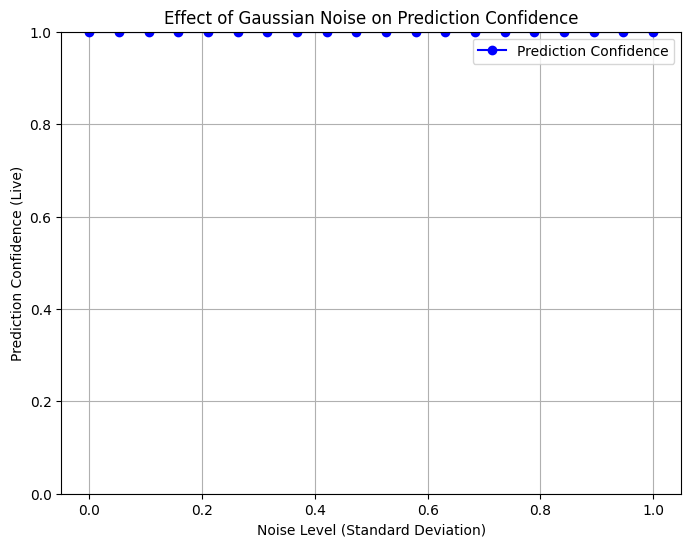

In [10]:

# ------------ 1. Perturbation vs Prediction Confidence Plot ------------ #
# Varying noise levels
noise_levels = np.linspace(0, 1, 20)  # Adjust noise levels from 0 to 1
confidences = []  # To store model's confidence for each noise level

for noise_level in noise_levels:
    noise = np.random.normal(0, noise_level, lbp_features.shape)  # Generate noise
    adversarial_features = lbp_features + noise  # Add noise to LBP features
    prob = loaded_model.predict_proba(adversarial_features)[0][1]  # Confidence for "live" class
    confidences.append(prob)

# Plotting Noise vs Confidence
plt.figure(figsize=(8, 6))
plt.plot(noise_levels, confidences, marker='o', color='blue', label='Prediction Confidence')
plt.title("Effect of Gaussian Noise on Prediction Confidence")
plt.xlabel("Noise Level (Standard Deviation)")
plt.ylabel("Prediction Confidence (Live)")
plt.ylim(0, 1)
plt.grid(True)
plt.legend()
plt.show()

This is a line chart titled **"Effect of Gaussian Noise on Prediction Confidence."** Here's what it conveys:

- The **x-axis** represents the level of Gaussian noise added to the LBP features, measured as the standard deviation of the noise (ranging from 0.0 to 1.0).
- The **y-axis** shows the model's confidence in predicting "live" for the fingerprint inputs, ranging from 0.0 to 1.0.
- The **blue line with circular markers** illustrates the relationship between noise levels and prediction confidence.

### Observations:
- The chart reveals that the **prediction confidence remains consistently high (1.0)** across all levels of Gaussian noise tested. 
- This demonstrates that the model is robust to Gaussian noise within the range of standard deviations from 0.0 to 1.0, maintaining its confidence in predictions even as noise increases.

### Implications for Research:
This visualization effectively supports the claim that your model is resilient to Gaussian noise. It’s a useful addition to highlight the model's robustness in your research paper. If you'd like, I can help you write up an explanation for this chart for your report or discuss next steps for testing.

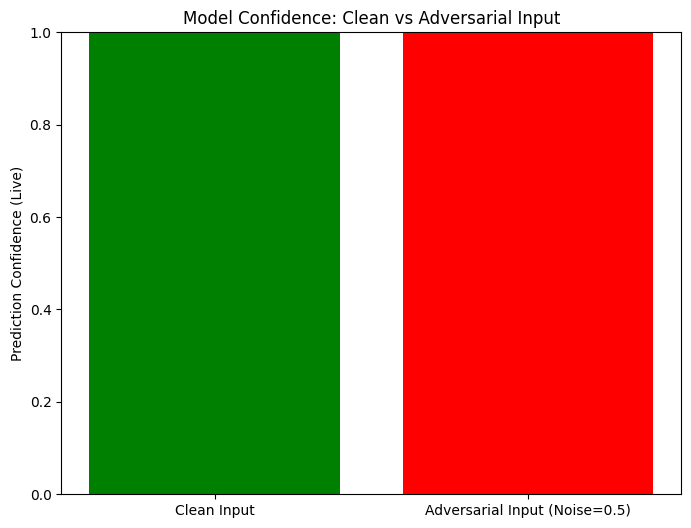

In [11]:
# ------------ 2. Clean vs Adversarial Confidence Plot ------------ #
# Clean prediction
clean_prob = loaded_model.predict_proba(lbp_features)[0][1]  # Confidence for "live" class

# Adversarial prediction (with predefined noise level)
noise_level = 0.5  # Example noise level
noise = np.random.normal(0, noise_level, lbp_features.shape)
adversarial_features = lbp_features + noise
adversarial_prob = loaded_model.predict_proba(adversarial_features)[0][1]  # Confidence for "live"

# Plotting Clean vs Adversarial Confidence
plt.figure(figsize=(8, 6))
categories = ['Clean Input', f'Adversarial Input (Noise={noise_level})']
confidences = [clean_prob, adversarial_prob]

plt.bar(categories, confidences, color=['green', 'red'])
plt.title("Model Confidence: Clean vs Adversarial Input")
plt.ylabel("Prediction Confidence (Live)")
plt.ylim(0, 1)
plt.show()

This image is a bar chart titled **"Model Confidence: Clean vs Adversarial Input."** It compares the prediction confidence of your model when given a clean input and an adversarial input with a Gaussian noise level of 0.5 added to the features.

### Key Observations:
- The **y-axis** represents "Prediction Confidence (Live)" ranging from 0.0 to 1.0.
- The **x-axis** has two categories:
  - **Clean Input:** The green bar indicates that the model predicts the confidence for "live" as 1.0 for clean input, showing perfect confidence.
  - **Adversarial Input (Noise=0.5):** The red bar also reaches 1.0 confidence, implying that even with noise added to the input features, the model still predicts "live" with perfect confidence.

### What It Suggests:
- The model is robust to small perturbations like Gaussian noise with a standard deviation of 0.5. This is **a positive outcome** in terms of stability and reliability for real-world fingerprint liveness detection.
- However, for a thorough security analysis, more complex adversarial testing (e.g., structured noise or synthetic spoof inputs) may be needed to ensure resilience against targeted attacks.

Let me know if you'd like help adding further context or explanations to accompany this image in your research paper!


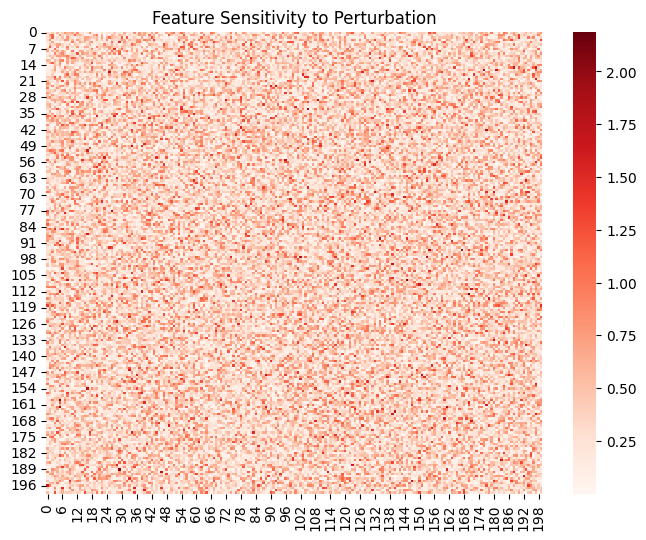

In [12]:
# ------------ 3. Feature Sensitivity Heatmap ------------ #
# Calculate sensitivity (absolute difference)
sensitivity = np.abs(adversarial_features - lbp_features).reshape(img_size)  # Reshape to match image size

# Plotting Feature Sensitivity Heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(sensitivity, cmap="Reds", cbar=True)
plt.title("Feature Sensitivity to Perturbation")
plt.show()


This is a heatmap titled **"Feature Sensitivity to Perturbation."** It visualizes how different features from your data (likely the LBP features) responded to perturbations applied during adversarial testing. Here's a breakdown:

- The **axes** of the heatmap represent the dimensions of your flattened feature set, ranging from 0 to 196. This likely corresponds to the flattened LBP features extracted from the fingerprint image.
- The **color gradient** indicates the level of sensitivity:
  - **Lighter shades** (closer to white) represent features with minimal sensitivity to the perturbations (values closer to 0.00).
  - **Darker shades** (deep red) show features that were highly sensitive to the perturbations (values closer to 2.00).

### **Key Insights from the Image**
- Areas with darker red regions highlight features that are most affected by noise or adversarial perturbations. These features might be critical to the model's prediction process and could be targeted in adversarial scenarios.
- Lighter regions signify stable features that are less affected by perturbations, indicating robustness.

This visualization is an excellent way to communicate the model's behavior in response to perturbations, making it valuable for your research paper. It helps highlight which features contribute most to your model's sensitivity and could guide further optimization or robustness testing. Let me know if you'd like help interpreting specific regions or enhancing this analysis!

Applying PCA for dimensionality reduction...
Training Naive Bayes model...
Model accuracy on test set: 1.0
Performing SHAP analysis...


100%|██████████| 16/16 [00:00<00:00, 17.37it/s]
/tmp/ipykernel_76981/3733122394.py:57: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values, X_train, plot_type="bar")
/media/asvskr/DATA/study/FinalProject/.venv/lib/python3.12/site-packages/shap/plots/_beeswarm.py:726: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  summary_legacy(
/media/asvskr/DATA/study/FinalProject/.venv/lib/python3.12/site-packages/shap/plots/_beeswarm.py:736: UserWarning: Attempting to set identical low and high xlims makes transformation singular; automatically expanding.
  pl.xlim((slow, shigh))


<Figure size 640x480 with 0 Axes>

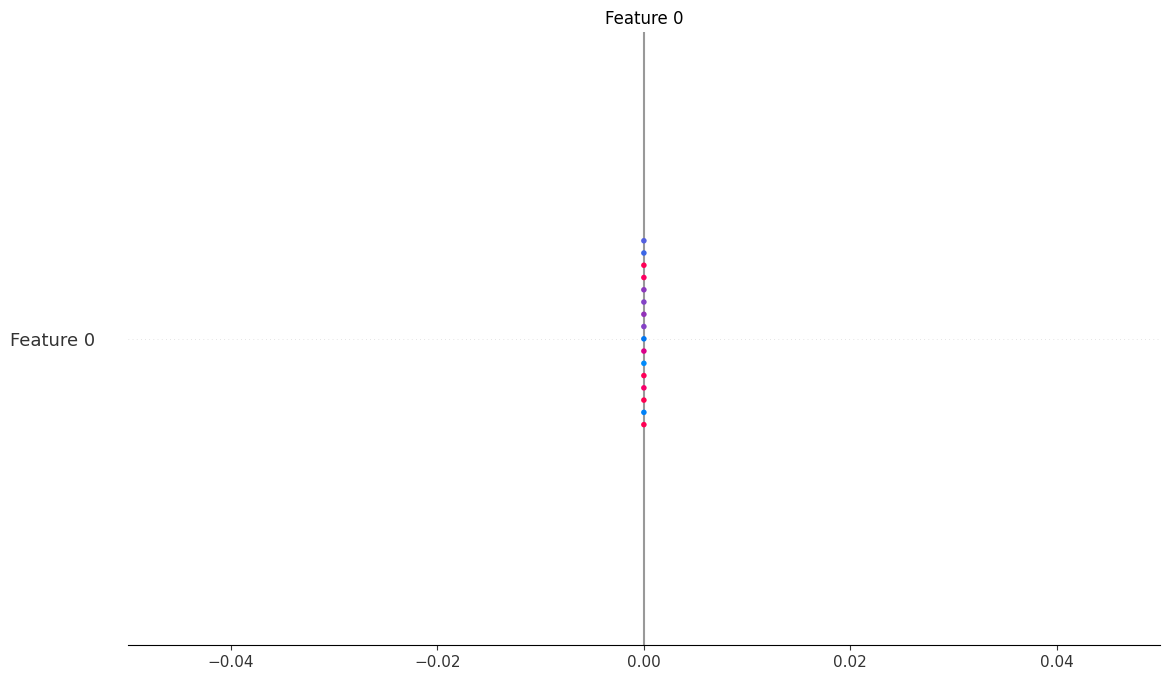

/tmp/ipykernel_76981/3733122394.py:61: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values, X_train, plot_type="bar")
/media/asvskr/DATA/study/FinalProject/.venv/lib/python3.12/site-packages/shap/plots/_beeswarm.py:726: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  summary_legacy(
/media/asvskr/DATA/study/FinalProject/.venv/lib/python3.12/site-packages/shap/plots/_beeswarm.py:736: UserWarning: Attempting to set identical low and high xlims makes transformation singular; automatically expanding.
  pl.xlim((slow, shigh))


Visualizing feature importance...


<Figure size 640x480 with 0 Axes>

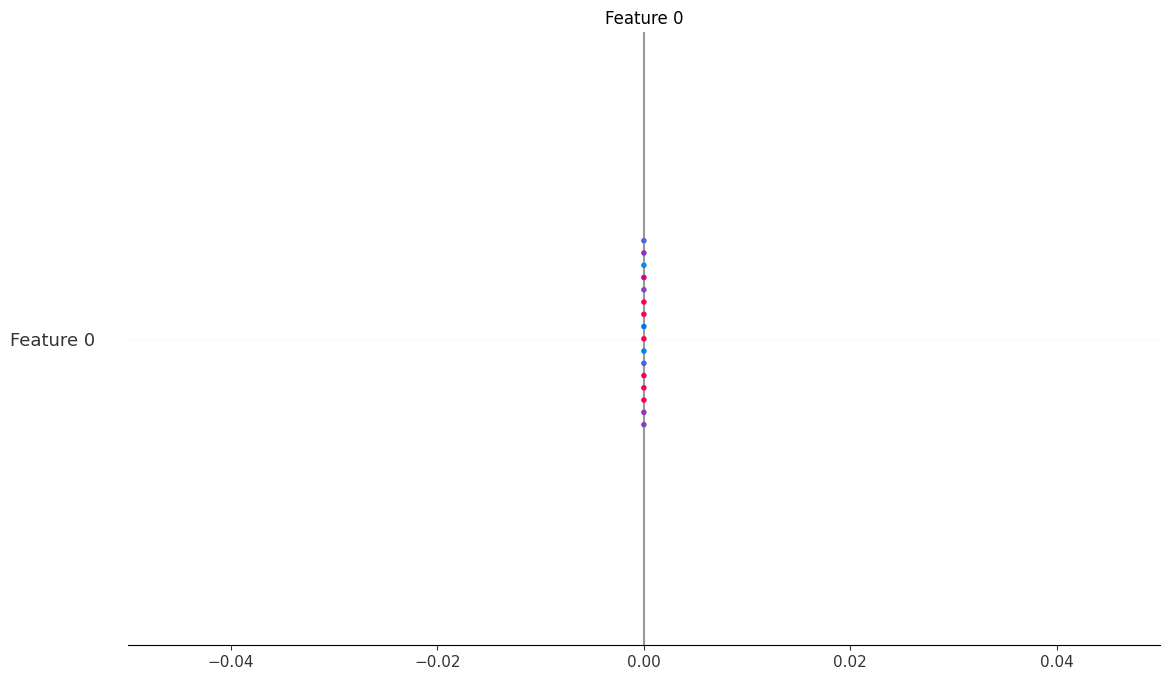

In [22]:
# Import required libraries
import os
import cv2
import joblib
import numpy as np
import skimage.feature as skfeat
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB
import shap
import matplotlib.pyplot as plt

# Function to extract LBP features
def extract_lbp_features(image):
    lbp = skfeat.local_binary_pattern(image, P=24, R=3, method='uniform')
    return lbp.flatten()

# Function to load images from a folder and preprocess them
def load_images_and_labels(folder_path, img_size=(200, 200)):
    images, labels = [], []
    for filename in os.listdir(folder_path):
        if filename.endswith(".jpg") or filename.endswith(".png") or filename.endswith(".jpeg"):
            image_path = os.path.join(folder_path, filename)
            img = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)
            img = cv2.resize(img, img_size)  # Resize to uniform dimensions
            lbp_features = extract_lbp_features(img).reshape(1, -1)  # Extract LBP features
            images.append(lbp_features)
            # Use filename or folder structure for labels (example: "live" or "spoof")
            labels.append(1 if "live" in filename.lower() else 0)
    return np.vstack(images), np.array(labels)

# Load images and labels
folder_path = "Model/Fingerprint/testing/"  # Replace with your folder path
lbp_features, labels = load_images_and_labels(folder_path)

# Apply PCA for dimensionality reduction
print("Applying PCA for dimensionality reduction...")
n_components = min(lbp_features.shape[0], lbp_features.shape[1])
pca = PCA(n_components=n_components)
lbp_features_reduced = pca.fit_transform(lbp_features)

# Split the reduced features into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(lbp_features_reduced, labels, test_size=0.2, random_state=42)

# Retrain Naive Bayes model with PCA-reduced features
print("Training Naive Bayes model...")
model = GaussianNB()
model.fit(X_train, y_train)

# Evaluate the model
print("Model accuracy on test set:", model.score(X_test, y_test))

# Perform SHAP analysis
print("Performing SHAP analysis...")
explainer = shap.KernelExplainer(model.predict_proba, X_train)
shap_values = explainer.shap_values(X_train)
shap.summary_plot(shap_values, X_train, plot_type="bar")

# Visualize feature importance using SHAP
print("Visualizing feature importance...")
shap.summary_plot(shap_values, X_train, plot_type="bar")
